# Advanced Segmentation Method (Mean Shift)

### Setup & libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# connect Google Drive
drive.mount('/content/drive')

# defining paths
base_path = '/content/drive/MyDrive/EWS-Dataset'
train_path = os.path.join(base_path, 'train')

Mounted at /content/drive


### Help function to load images
Loads the Original picture & the corresponding ground-truth-mask

In [11]:

def load_image_and_mask(folder_path, index=0):  # index of img
    # find all normal pictures (no mask)
    image_files = sorted([f for f in os.listdir(folder_path) if not f.endswith('mask.png') and f.endswith(('.jpg', '.png'))])

    img_name = image_files[index]
    img_path = os.path.join(folder_path, img_name)

    # mask img
    mask_name = img_name.rsplit('.', 1)[0] + '_mask.png'
    mask_path = os.path.join(folder_path, mask_name)

    # load img (BGR to RGB for the original img)
    img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    # load mask (grayscale, because its only black & white)
    true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    # make the mask binary(0/1) -Soil=1; Wheat=0
    _, true_mask = cv2.threshold(true_mask, 127, 1, cv2.THRESH_BINARY)

    return img_rgb, true_mask, img_name

# testing
test_img, test_true_mask, img_name = load_image_and_mask(train_path, index=0)
print(f"Bild geladen: {img_name}")

Bild geladen: FPWW0220011_RGB1_20180316_100219_6.png


### Segmentation Method
Main Method: Mean Shift + Morphologie

In [12]:
def segment_wheat_meanshift(image_rgb): #takes a RGB img and gives a calculated binary mask (0 & 1) back

    # 0. Mean Shift Filtering - smoothes textures to remove noise (took it out again because it decreases overall performance a bit)
    # shifted = cv2.pyrMeanShiftFiltering(image_rgb, sp=5, sr=15)  # sp = Spatial Window Radius, sr = Color Window Radius

    # 1. Transformation into HSV-colorspace (better for finding green colors in shadow)
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV) # for smoothed img "shifted" instead of "image_rgb"

    # 2. determine color-threshold  ### maybe tune parameters here later
    # H (color), S (saturation), V (brightness/intesity)
    lower_green = np.array([25, 35, 35])  # lower limit for wheatgreen/yellow
    upper_green = np.array([95, 255, 255]) # upper limit

    # create preliminary Mask
    predicted_mask = cv2.inRange(hsv, lower_green, upper_green)

    # 3. Morphological Post-processing
    kernel = np.ones((3,3), np.uint8)

    # Opening: removes small noise/dots in the background (soil)
    predicted_mask = cv2.morphologyEx(predicted_mask, cv2.MORPH_OPEN, kernel)

    # Closing: fills small holes within the wheat leaves
    predicted_mask = cv2.morphologyEx(predicted_mask, cv2.MORPH_CLOSE, kernel)

    # normalize mask to values 0 and 1 (for better comparison with real mask)
    predicted_mask = (predicted_mask > 0).astype(np.uint8)
    predicted_mask = 1 - predicted_mask # convert: 1->0 (Wheat), 0->1 (Background)

    return predicted_mask

# execute the segmentation on the test image
my_predicted_mask = segment_wheat_meanshift(test_img)
print("mask was calculated")

mask was calculated


### Evaluation & Visualization
IoU (Intersection over Union metric) and results visualization

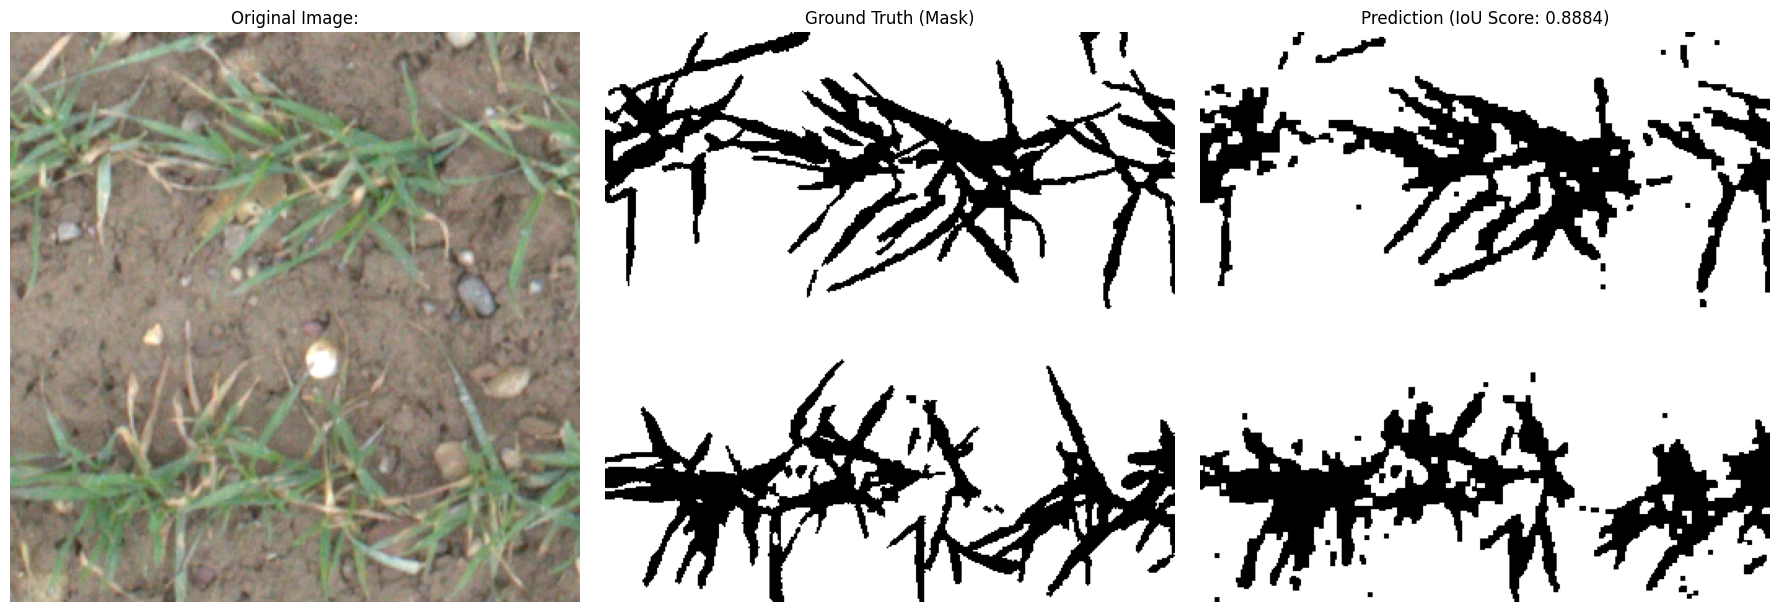

In [13]:
def calculate_iou(mask_true, mask_pred):
    intersection = np.logical_and(mask_true, mask_pred)
    union = np.logical_or(mask_true, mask_pred)

    if np.sum(union) == 0:  # avoid division by 0 if union is empty
        return 0

    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

# calculate performance score
iou = calculate_iou(test_true_mask, my_predicted_mask)

# plotting results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(test_img)
axes[0].set_title('Original Image:')
axes[0].axis('off')

# display Ground Truth (multiplied by 255 so that 1 turns into white )
axes[1].imshow(test_true_mask * 255, cmap='gray')
axes[1].set_title('Ground Truth (Mask)')
axes[1].axis('off')

# display prediction
axes[2].imshow(my_predicted_mask * 255, cmap='gray')
axes[2].set_title(f'Prediction (IoU Score: {iou:.4f})')
axes[2].axis('off')

plt.tight_layout()
plt.show()